In [1]:
import pandas as pd
import os

In [2]:
metrics = {
            "MATTR" : [],
            "L_MATTR" : [],
            "LEX_DEN" : [],
            "UNIQUE_WORDS" : [],
            "FLESCH" : [],
            "GUNNING_FOG" : [],
            "AVG_SENT_LEN" : [],
            "LONG_SENTS" : [],
            "SHORT_SENTS" : [],
            "SENT_LEN_STD" : [],
            "len_in_characters" : [],
            "polarity" : [],
            "subjectivity" : [],
            'POS_VERB':[],
            'POS_NOUN': [],
            'POS_ADJ': [],
            'POS_ADV': [],
            'POS_DET':[],
            'POS_INTJ':[],
            'POS_CONJ':[],
            'POS_PART':[],
            'POS_NUM':[],
            'POS_PREP':[],
            'POS_PRO':[],
            'G_PASSIVE':[],
            'G_ACTIVE':[],
            'G_PRESENT':[],
            'G_PAST':[],
            'G_FUTURE':[],
            'L_CONT_A': [],
            'L_FUNC_A': [],
            'L_CONT_T': [],
            'L_FUNC_T': [],
            'L_PROPER_NAME': [], 
            'L_PERSONAL_NAME': [],
            'L_POSSESSIVES': [],
            'L_ADJ_POSITIVE': [],
            'L_ADJ_COMPARATIVE': [],
            'L_ADJ_SUPERLATIVE': [],
            'L_ADV_POSITIVE': [],
            'L_ADV_COMPARATIVE': [],
            'L_ADV_SUPERLATIVE': [],
            'ST_REPETITIONS_WORDS': [],
            'ST_REPETITIONS_SENT': [],
            'L_I_PRON': [],
            'L_HE_PRON': [],
            'L_SHE_PRON': [],
            'L_IT_PRON': [],
            'L_YOU_PRON': [],
            'L_WE_PRON': [],
            'L_THEY_PRON': [],
            'L_ME_PRON': [],
            'L_YOU_OBJ_PRON': [], 
            'L_HIM_PRON': [],
            'L_HER_OBJECT_PRON': [], 
            'L_IT_OBJECT_PRON': [],
            'L_US_PRON': [],
            'L_THEM_PRON': [],
            'L_MY_PRON': [],
            'L_YOUR_PRON': [],
            'L_HIS_PRON': [],
            'L_HER_PRON': [],
            'L_ITS_PRON': [],
            'L_OUR_PRON': [],
            'L_THEIR_PRON': [],
            'L_YOURS_PRON': [],
            'L_THEIRS_PRON': [],
            'L_HERS_PRON': [],
            'L_OURS_PRON': [],
            'L_MYSELF_PRON': [],
            'L_YOURSELF_PRON': [],
            'L_HIMSELF_PRON': [],
            'L_HERSELF_PRON': [],
            'L_ITSELF_PRON': [],
            'L_OURSELVES_PRON': [],
            'L_YOURSELVES_PRON': [],
            'L_THEMSELVES_PRON': [],
            'L_FIRST_PERSON_SING_PRON': [],
            'L_SECOND_PERSON_PRON': [],
            'L_THIRD_PERSON_SING_PRON': [],
            'L_THIRD_PERSON_PLURAL_PRON': [],
            'VF_INFINITIVE': [],
            }


datasets = ['abstracts', 'news', 'reviews', 'qa']
models = ['mistral', 'deepseek', 'llama3.3', 'qwen72b', 'qwen32b', 'qwen14b', 'solar']
prompts = ['zero_shot_baseline', 'in_context_learning_3-shot', 'style_information_style_example',
           'chain_of_thought_zero_shot', 'chain_of_thought_one_shot',  "self-refine"]
detection_models = ["microsoft/deberta-v3-small", "xlm-roberta-base"]

In [3]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

def calculate_overall_correlation(df1, df2, method='pearson', alpha=0.05):
    """
    Calculate a single correlation value between two 2D DataFrames (flattened).
    
    Parameters:
    - df1, df2: pandas DataFrames (will be flattened into 1D arrays)
    - method: 'pearson' (default) or 'spearman'
    - alpha: significance level (default: 0.05)
    
    Returns:
    - corr: correlation coefficient
    - p_value: p-value of the correlation
    - is_significant: True if p < alpha, else False
    """
    
    # Flatten DataFrames into 1D arrays
    flat_df1 = df1.values.flatten()
    flat_df2 = df2.values.flatten()
    
    # Remove NaN values (pairwise deletion)
    mask = ~np.isnan(flat_df1) & ~np.isnan(flat_df2)
    x = flat_df1[mask]
    y = flat_df2[mask]
    
    # Check for constant arrays
    if np.all(x == x[0]) or np.all(y == y[0]):
        corr, p_value = np.nan, np.nan
    
    if len(x) < 3:
        raise ValueError("Not enough non-NaN values to compute correlation (need ≥3).")
    try:
        # Compute correlation
        if method == 'pearson':
            corr, p_value = pearsonr(x, y)
        elif method == 'spearman':
            corr, p_value = spearmanr(x, y)
        else:
            raise ValueError("Method must be 'pearson' or 'spearman'.")
    except (ValueError, RuntimeWarning):
        corr, p_value = np.nan, np.nan
    
    # Determine significance
    is_significant = p_value < alpha
    
    return corr, p_value, is_significant

In [4]:
acc_df = pd.read_csv('heatmap_acces/'+"microsoft/deberta-v3-small" + '/' + 'prompt_' + "mistral" + '_' + "qa" + '.csv', index_col=0)
acc_df.set_index(acc_df.columns[0])

,zero_shot_baseline,in_context_learning_3-shot,style_information_style_example,chain_of_thought_zero_shot,chain_of_thought_one_shot,self-refine
train_prompt_type,,,,,,
zero_shot_baseline,0.9014,0.8623,0.8982,0.9019,0.8987,0.8972
in_context_learning_3-shot,0.9182,0.9167,0.9146,0.9103,0.9209,0.9209
style_information_style_example,0.8782,0.7896,0.8819,0.8813,0.8745,0.8776
chain_of_thought_zero_shot,0.8312,0.7637,0.8312,0.8333,0.8238,0.8259
chain_of_thought_one_shot,0.9272,0.8850,0.9235,0.9246,0.9299,0.9235
self-refine,0.8423,0.6566,0.8866,0.8339,0.7848,0.9905


In [5]:
feature_df = pd.read_csv('heatmap_features/'+ "G_PASSIVE" + '_prompt_' + "mistral" + '_' + "qa" + '.csv', index_col=0)
feature_df

,zero_shot_baseline,in_context_learning_3-shot,style_information_style_example,chain_of_thought_zero_shot,chain_of_thought_one_shot,self-refine
0,0.000000,-0.000567,0.005495,0.000332,-0.001664,0.014892
1,0.000567,0.000000,0.006062,0.000900,-0.001096,0.015459
2,-0.005495,-0.006062,0.000000,-0.005162,-0.007159,0.009397
3,-0.000332,-0.000900,0.005162,0.000000,-0.001996,0.014560
4,0.001664,0.001096,0.007159,0.001996,0.000000,0.016556
5,-0.014892,-0.015459,-0.009397,-0.014560,-0.016556,0.000000


In [6]:
## prompt
prompt_corr_df = pd.DataFrame()
metric_df = []
data_df = []
model_df = []
corr_df = []
p_df = []
sig_df = []
detection_model_df = []

prompt_overall_df = pd.DataFrame()
overall_detection_model_df = []
overall_metric_df = []
overall_corr_df = []
overall_p_df = []
overall_sig_df = []

prompt_dif_model_df = pd.DataFrame()
dif_model_detection_model_df = []
dif_model_metric_df = []
dif_model_corr_df = []
dif_model_p_df = []
dif_model_sig_df = []
dif_model_df = []

for detection_model in ["microsoft/deberta-v3-small", "xlm-roberta-base"]:
    for metric in metrics.keys():
        overall_feature_df = pd.DataFrame()
        overall_acc_df = pd.DataFrame()
        for model in models:
            model_feature_df = pd.DataFrame()
            model_acc_df = pd.DataFrame()
            
            for data in datasets:
                metric_df.append(metric)
                data_df.append(data)
                model_df.append(model)
                detection_model_df.append(detection_model)
                feature_df = pd.read_csv('heatmap_features/'+ metric + '_prompt_' + model + '_' + data + '.csv', index_col=0)
                acc_df = pd.read_csv('heatmap_acces/'+detection_model + '/' + 'prompt_' + model + '_' + data + '.csv', index_col=0)
                corr, p_value, is_significant = calculate_overall_correlation(acc_df.set_index(acc_df.columns[0]), feature_df, method='pearson')

                corr_df.append(corr)
                p_df.append(p_value)
                sig_df.append(p_value<0.05)

                
                overall_feature_df= pd.concat([overall_feature_df, feature_df])
                overall_acc_df = pd.concat([overall_acc_df, acc_df])
                
                model_feature_df= pd.concat([model_feature_df, feature_df])
                model_acc_df = pd.concat([model_acc_df, acc_df])

            corr, p_value, is_significant = calculate_overall_correlation(model_acc_df.set_index(model_acc_df.columns[0]), model_feature_df, method='pearson')
            dif_model_detection_model_df.append(detection_model)
            dif_model_metric_df.append(metric)
            dif_model_corr_df.append(corr)
            dif_model_p_df.append(p_value)
            dif_model_sig_df.append(is_significant)
            dif_model_df.append(model)

        corr, p_value, is_significant = calculate_overall_correlation(overall_acc_df.set_index(overall_acc_df.columns[0]), overall_feature_df, method='spearman')
        overall_detection_model_df.append(detection_model)
        overall_metric_df.append(metric)
        overall_corr_df.append(corr)
        overall_p_df.append(p_value)
        overall_sig_df.append(is_significant)

        
prompt_corr_df['detection_model'] = detection_model_df
prompt_corr_df['metric'] = metric_df
prompt_corr_df['dataset'] = data_df
prompt_corr_df['model'] = model_df
prompt_corr_df['correlation'] = corr_df
prompt_corr_df['pvalue'] = p_df
prompt_corr_df['significant'] = sig_df

prompt_dif_model_df['detection_model'] = dif_model_detection_model_df
prompt_dif_model_df['metric'] = dif_model_metric_df
prompt_dif_model_df['model'] = dif_model_df
prompt_dif_model_df['correlation'] = dif_model_corr_df
prompt_dif_model_df['pvalue'] = dif_model_p_df
prompt_dif_model_df['significant'] = dif_model_sig_df


prompt_overall_df['detection_model'] = overall_detection_model_df
prompt_overall_df['metric'] = overall_metric_df
prompt_overall_df['correlation'] = overall_corr_df
prompt_overall_df['pvalue'] = overall_p_df
prompt_overall_df['significant'] = overall_sig_df


prompt_corr_df.to_csv('heatmap_corr/prompt_corr_result.csv', index=False)
prompt_dif_model_df.to_csv('heatmap_corr/prompt_diff_model_corr_result.csv', index=False)
prompt_overall_df.to_csv('heatmap_corr/overall_prompt_spearman_corr_result.csv', index=False)
            

/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y

In [7]:
prompt_overall_df

,detection_model,metric,correlation,pvalue,significant
0,microsoft/deberta-v3-small,MATTR,0.002080,0.947413,False
1,microsoft/deberta-v3-small,L_MATTR,-0.013442,0.669923,False
2,microsoft/deberta-v3-small,LEX_DEN,-0.016293,0.605376,False
3,microsoft/deberta-v3-small,UNIQUE_WORDS,0.025143,0.425218,False
4,microsoft/deberta-v3-small,FLESCH,0.061710,0.050150,False
...,...,...,...,...,...
159,xlm-roberta-base,L_FIRST_PERSON_SING_PRON,0.043003,0.172487,False
160,xlm-roberta-base,L_SECOND_PERSON_PRON,0.030280,0.336853,False
161,xlm-roberta-base,L_THIRD_PERSON_SING_PRON,0.007824,0.804046,False
162,xlm-roberta-base,L_THIRD_PERSON_PLURAL_PRON,-0.003180,0.919690,False


In [8]:
## model
model_corr_df = pd.DataFrame()
metric_df = []
data_df = []
model_df = []
corr_df = []
p_df = []
sig_df = []
detection_model_df = []

model_overall_df = pd.DataFrame()
overall_detection_model_df = []
overall_metric_df = []
overall_corr_df = []
overall_p_df = []
overall_sig_df = []

for detection_model in ["microsoft/deberta-v3-small", "xlm-roberta-base"]:
    for metric  in metrics.keys():
        overall_feature_df = pd.DataFrame()
        overall_acc_df = pd.DataFrame()
        for data in datasets:
            # for model in models:
                metric_df.append(metric)
                data_df.append(data)
                detection_model_df.append(detection_model)
                feature_df = pd.read_csv('heatmap_features/'+ metric + '_zero_shot_baseline_model_' + data + '.csv', index_col=0)
                acc_df = pd.read_csv('heatmap_acces/'+ detection_model + '/' + 'zero_shot_baseline_model_' + data + '.csv', index_col=0)
                corr, p_value, is_significant = calculate_overall_correlation(acc_df, feature_df, method='pearson')
                corr_df.append(corr)
                p_df.append(p_value)
                sig_df.append(p_value<0.05)

                overall_feature_df= pd.concat([overall_feature_df, feature_df])
                overall_acc_df = pd.concat([overall_acc_df, acc_df])
                
                
        corr, p_value, is_significant = calculate_overall_correlation(overall_acc_df, overall_feature_df, method='spearman')
        overall_detection_model_df.append(detection_model)
        overall_metric_df.append(metric)
        overall_corr_df.append(corr)
        overall_p_df.append(p_value)
        overall_sig_df.append(p_value<0.05)

model_corr_df['detection_model'] = detection_model_df
model_corr_df['metric'] = metric_df
model_corr_df['dataset'] = data_df
# model_corr_df['model'] = model_df
model_corr_df['correlation'] = corr_df
model_corr_df['pvalue'] = p_df
model_corr_df['significant'] = sig_df

model_overall_df['detection_model'] = overall_detection_model_df
model_overall_df['metric'] = overall_metric_df
model_overall_df['correlation'] = overall_corr_df
model_overall_df['pvalue'] = overall_p_df
model_overall_df['significant'] = overall_sig_df


model_corr_df.to_csv('heatmap_corr/model_corr_result.csv', index=False)


model_overall_df.to_csv('heatmap_corr/overall_model_spearman_corr_result.csv', index=False)
            

/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:40: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, 

In [9]:
## dataset
data_corr_df = pd.DataFrame()
metric_df = []
data_df = []
model_df = []
corr_df = []
p_df = []
sig_df = []
detection_model_df = []

data_overall_df = pd.DataFrame()
overall_detection_model_df = []
overall_metric_df = []
overall_corr_df = []
overall_p_df = []
overall_sig_df = []

for detection_model in ["microsoft/deberta-v3-small", "xlm-roberta-base"]:
    for metric  in metrics.keys():
        overall_feature_df = pd.DataFrame()
        overall_acc_df = pd.DataFrame()
        for model in models:
            # for model in models:
                metric_df.append(metric)
                # data_df.append(data)
                model_df.append(model)
                detection_model_df.append(detection_model)
                feature_df = pd.read_csv('heatmap_features/'+ metric + '_zero_shot_baseline_' + model + '_data.csv', index_col=0)
                acc_df = pd.read_csv('heatmap_acces/'+ detection_model + '/' + 'zero_shot_baseline_'+ model + '_data.csv', index_col=0)
                corr, p_value, is_significant = calculate_overall_correlation(acc_df, feature_df, method='pearson')
                corr_df.append(corr)
                p_df.append(p_value)
                sig_df.append(p_value<0.05)
                
                
                overall_feature_df= pd.concat([overall_feature_df, feature_df])
                overall_acc_df = pd.concat([overall_acc_df, acc_df])
                
        
        corr, p_value, is_significant = calculate_overall_correlation(overall_acc_df, overall_feature_df, method='spearman')
        overall_detection_model_df.append(detection_model)
        overall_metric_df.append(metric)
        overall_corr_df.append(corr)
        overall_p_df.append(p_value)
        overall_sig_df.append(p_value<0.05)

data_corr_df['detection_model'] = detection_model_df
data_corr_df['metric'] = metric_df
# data_corr_df['dataset'] = data_df
data_corr_df['model'] = model_df
data_corr_df['correlation'] = corr_df
data_corr_df['pvalue'] = p_df
data_corr_df['significant'] = sig_df

data_overall_df['detection_model'] = overall_detection_model_df
data_overall_df['metric'] = overall_metric_df
data_overall_df['correlation'] = overall_corr_df
data_overall_df['pvalue'] = overall_p_df
data_overall_df['significant'] = overall_sig_df


data_corr_df.to_csv('heatmap_corr/data_corr_result.csv', index=False)

data_overall_df.to_csv('heatmap_corr/overall_data_spearman_corr_result.csv', index=False)
            

/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y)
/tmp/ipykernel_3872341/557313162.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = pearsonr(x, y

In [10]:
overall_generalization_df = pd.DataFrame(columns=['feature', 'metric', 'deberta_prompt', 'deberta_model', 'deberta_data', 'roberta_prompt', 'roberta_model', 'roberta_data'])
overall_generalization_df['feature'], overall_generalization_df['metric'] = ['' for i in metrics.keys()], metrics.keys()
overall_generalization_df['deberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['correlation'].values
overall_generalization_df['deberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['correlation'].values
overall_generalization_df['deberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['correlation'].values

overall_generalization_df['roberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'xlm-roberta-base']['correlation'].values
overall_generalization_df['roberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'xlm-roberta-base']['correlation'].values
overall_generalization_df['roberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'xlm-roberta-base']['correlation'].values


overall_generalization_df.to_csv('heatmap_corr/overall_generalization_corr_result.csv', index=False)


In [11]:
overall_pvalue_df = pd.DataFrame(columns=['feature', 'metric', 'deberta_prompt', 'deberta_model', 'deberta_data', 'roberta_prompt', 'roberta_model', 'roberta_data'])
overall_pvalue_df['feature'], overall_pvalue_df['metric'] = ['' for i in metrics.keys()], metrics.keys()
overall_pvalue_df['deberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['pvalue'].values
overall_pvalue_df['deberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['pvalue'].values
overall_pvalue_df['deberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['pvalue'].values

overall_pvalue_df['roberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'xlm-roberta-base']['pvalue'].values
overall_pvalue_df['roberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'xlm-roberta-base']['pvalue'].values
overall_pvalue_df['roberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'xlm-roberta-base']['pvalue'].values


overall_pvalue_df.to_csv('heatmap_corr/overall_generalization_pvalue_result.csv', index=False)

In [12]:
overall_sig_df = pd.DataFrame(columns=['feature', 'metric', 'deberta_prompt', 'deberta_model', 'deberta_data', 'roberta_prompt', 'roberta_model', 'roberta_data'])
overall_sig_df['feature'], overall_sig_df['metric'] = ['' for i in metrics.keys()], metrics.keys()
overall_sig_df['deberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['significant'].values
overall_sig_df['deberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['significant'].values
overall_sig_df['deberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'microsoft/deberta-v3-small']['significant'].values

overall_sig_df['roberta_prompt'] = prompt_overall_df[prompt_overall_df['detection_model'] == 'xlm-roberta-base']['significant'].values
overall_sig_df['roberta_model'] = model_overall_df[model_overall_df['detection_model'] == 'xlm-roberta-base']['significant'].values
overall_sig_df['roberta_data'] = data_overall_df[data_overall_df['detection_model'] == 'xlm-roberta-base']['significant'].values


overall_sig_df.to_csv('heatmap_corr/overall_generalization_sig_result.csv', index=False)

In [13]:

def csv_to_latex_with_significance(results_file, significance_file, output_file):
    # Read both CSV files
    results_df = pd.read_csv(results_file)
    results_df = results_df
    significance_df = pd.read_csv(significance_file)
    
    # Ensure both DataFrames have the same shape
    if results_df.shape != significance_df.shape:
        raise ValueError("Results and significance tables must have the same dimensions")
    
    # Create a copy for processing
    processed_df = results_df.copy()
    
    # Convert numeric columns (excluding first column if it's text)
    numeric_cols = []
    for j in range(len(results_df.columns)):
        # Skip first column if it's non-numeric
        if j == 0 and not pd.api.types.is_numeric_dtype(results_df.iloc[:, j]):
            continue
        try:
            processed_df.iloc[:, j] = pd.to_numeric(processed_df.iloc[:, j])
            numeric_cols.append(j)
        except ValueError:
            pass
    
    # Find top 3 maximum values in each numeric column
    top_values = {}
    for j in numeric_cols:
        col = abs(processed_df.iloc[:, j])
        # Get indices of top 3 values (sorted descending)
        top_indices = col.sort_values(ascending=False).head(3).index.tolist()
        top_values[j] = {
            'max': top_indices[0] if len(top_indices) > 0 else None,
            'second': top_indices[1] if len(top_indices) > 1 else None,
            'third': top_indices[2] if len(top_indices) > 2 else None
        }
    
    # Process each cell
    latex_rows = []
    for i in range(len(results_df)):
        row = []
        for j in range(len(results_df.columns)):
            # Handle first column (labels)
            if j == 0 and not pd.api.types.is_numeric_dtype(results_df.iloc[:, j]):
                row.append(str(results_df.iloc[i, j]))
                continue
                
            # Process numeric values
            try:
                value = results_df.iloc[i, j]
                numeric_value = float(value)
                # Round to 3 decimal places
                rounded_value = abs(round(numeric_value, 3))
                # Format to show 3 decimal places when needed
                if rounded_value == int(rounded_value):
                    value_str = f"{int(rounded_value)}"
                else:
                    value_str = f"{rounded_value:.3f}".rstrip('0').rstrip('.') if '.' in f"{rounded_value:.3f}" else f"{rounded_value:.0f}"
                    if '.' in value_str and len(value_str.split('.')[1]) < 3:
                        value_str = f"{rounded_value:.3f}"
                
                # Check significance
                sig = significance_df.iloc[i, j]
                is_significant = not (pd.isna(sig) or str(sig).lower() in ['false', '0', 'no', 'nan', ''])
                
                # Check if this is a top value
                is_max = j in numeric_cols and i == top_values[j]['max']
                is_second = j in numeric_cols and i == top_values[j]['second']
                is_third = j in numeric_cols and i == top_values[j]['third']
                
                # Apply formatting
                if is_significant:
                    value_str = f"\\textbf{{{value_str}}}"
                    if is_max:
                        value_str = f"\\textbf{{\\underline{{{value_str}}}}}"
                    elif is_second or is_third:
                        value_str = f"\\textit{{{value_str}}}"
                
                row.append(value_str)
                
            except (ValueError, TypeError):
                # Handle non-numeric values
                row.append(str(results_df.iloc[i, j]))
        
        latex_rows.append(" & ".join(row) + " \\\\")
    
    # Create LaTeX table header
    header = " & ".join(results_df.columns) + " \\\\"
    
    
    # Combine everything
    latex_table = [
        "\\begin{table}[ht]",
        "\\centering",
        "\\begin{tabular}{" + "l" + "c" * (len(results_df.columns) - 1) + "}",
        "\\toprule",
        header,
        "\\midrule",
        *latex_rows,
        "\\bottomrule",
        "\\end{tabular}",
        "\\caption{Your caption here}",
        "\\label{tab:your_label}",
        "\\end{table}"
    ]

    with open(output_file, 'w') as f:
        f.write("\n".join(latex_table))
    

    print(latex_table)

# Example usage
csv_to_latex_with_significance(
    results_file='heatmap_corr/overall_generalization_corr_result.csv',
    significance_file='heatmap_corr/overall_generalization_sig_result.csv',
    output_file="heatmap_corr/output_table.tex"
)

['\\begin{table}[ht]', '\\centering', '\\begin{tabular}{lccccccc}', '\\toprule', 'feature & metric & deberta_prompt & deberta_model & deberta_data & roberta_prompt & roberta_model & roberta_data \\\\', '\\midrule', 'nan & MATTR & 0.002 & \\textit{\\textbf{0.326}} & 0.141 & 0.012 & \\textbf{0.334} & 0.118 \\\\', 'nan & L_MATTR & 0.013 & \\textbf{\\underline{\\textbf{0.338}}} & 0.107 & 0.008 & \\textbf{0.360} & 0.077 \\\\', 'nan & LEX_DEN & 0.016 & \\textbf{0.296} & 0.099 & 0.028 & \\textit{\\textbf{0.362}} & 0.179 \\\\', 'nan & UNIQUE_WORDS & 0.025 & 0.121 & 0.173 & 0.022 & \\textbf{0.145} & 0.100 \\\\', 'nan & FLESCH & 0.062 & \\textit{\\textbf{0.322}} & \\textbf{0.222} & 0.059 & \\textbf{0.359} & \\textit{\\textbf{0.262}} \\\\', 'nan & GUNNING_FOG & \\textbf{0.089} & \\textbf{0.317} & \\textbf{0.266} & \\textbf{0.087} & \\textbf{0.345} & \\textbf{\\underline{\\textbf{0.277}}} \\\\', 'nan & AVG_SENT_LEN & \\textbf{0.077} & \\textbf{0.295} & 0.171 & \\textbf{0.074} & \\textbf{0.315} & 0

In [14]:
## Deberta
## prompt
dfs = []
for model in models:
    for data in datasets:
        sep_df = pd.read_csv('heatmap_features/' + 'G_PASSIVE_prompt_' + model + '_' + data +'.csv', index_col=0)
        dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_prompt_avg_feature_df = pd.DataFrame(average_array)


dfs = []
for data in datasets:
    sep_df = pd.read_csv('heatmap_features/' + 'G_PAST_zero_shot_baseline_model' + '_' + data +'.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_model_avg_feature_df = pd.DataFrame(average_array)


dfs = []
for model in models:
    sep_df = pd.read_csv('heatmap_features/' + 'G_PASSIVE_zero_shot_baseline_' +model+ '_data.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_data_avg_feature_df = pd.DataFrame(average_array)

In [15]:
## Deberta
## prompt
dfs = []
for model in models:
    for data in datasets:
        sep_df = pd.read_csv('heatmap_features/' + 'G_PRESENT_prompt_' + model + '_' + data +'.csv', index_col=0)
        dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
roberta_prompt_avg_feature_df = pd.DataFrame(average_array)


dfs = []
for data in datasets:
    sep_df = pd.read_csv('heatmap_features/' + 'L_IT_OBJECT_PRON_zero_shot_baseline_model' + '_' + data +'.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
roberta_model_avg_feature_df = pd.DataFrame(average_array)


dfs = []
for model in models:
    sep_df = pd.read_csv('heatmap_features/' + 'G_PASSIVE_zero_shot_baseline_' +model+ '_data.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
roberta_data_avg_feature_df = pd.DataFrame(average_array)

In [16]:
## Deberta
## prompt

dfs = []
for model in models:
    for data in datasets:
        sep_df = pd.read_csv('heatmap_features/' + 'G_PASSIVE_prompt_' + model + '_' + data +'.csv', index_col=0)
        # sep_df_1 = pd.read_csv('heatmap_features/' + 'G_PASSIVE_prompt_' + model + '_' + data +'.csv', index_col=0)
        # sep_df_2 = pd.read_csv('heatmap_features/' + 'L_ADJ_SUPERLATIVE_prompt_' + model + '_' + data +'.csv', index_col=0)
        # sep_df_3 = pd.read_csv('heatmap_features/' + 'POS_NUM_prompt_' + model + '_' + data +'.csv', index_col=0)
        # sep_df = np.sqrt(sep_df_1**2 + sep_df_2**2 + sep_df_3**2)
        dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_prompt_avg_feature_df = -pd.DataFrame(average_array)


dfs = []
for data in datasets:
    sep_df = pd.read_csv('heatmap_features/' + 'G_PAST_zero_shot_baseline_model' + '_' + data +'.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_model_avg_feature_df = pd.DataFrame(average_array)


dfs = []
for model in models:
    sep_df = pd.read_csv('heatmap_features/' + 'G_PASSIVE_zero_shot_baseline_' +model+ '_data.csv', index_col=0)
    dfs.append(sep_df*100)

arrays = [df.values for df in dfs]
# Average the arrays element-wise
average_array = np.mean(arrays, axis=0)
# Convert the result back to a DataFrame (optional)
deberta_data_avg_feature_df = pd.DataFrame(average_array)

6


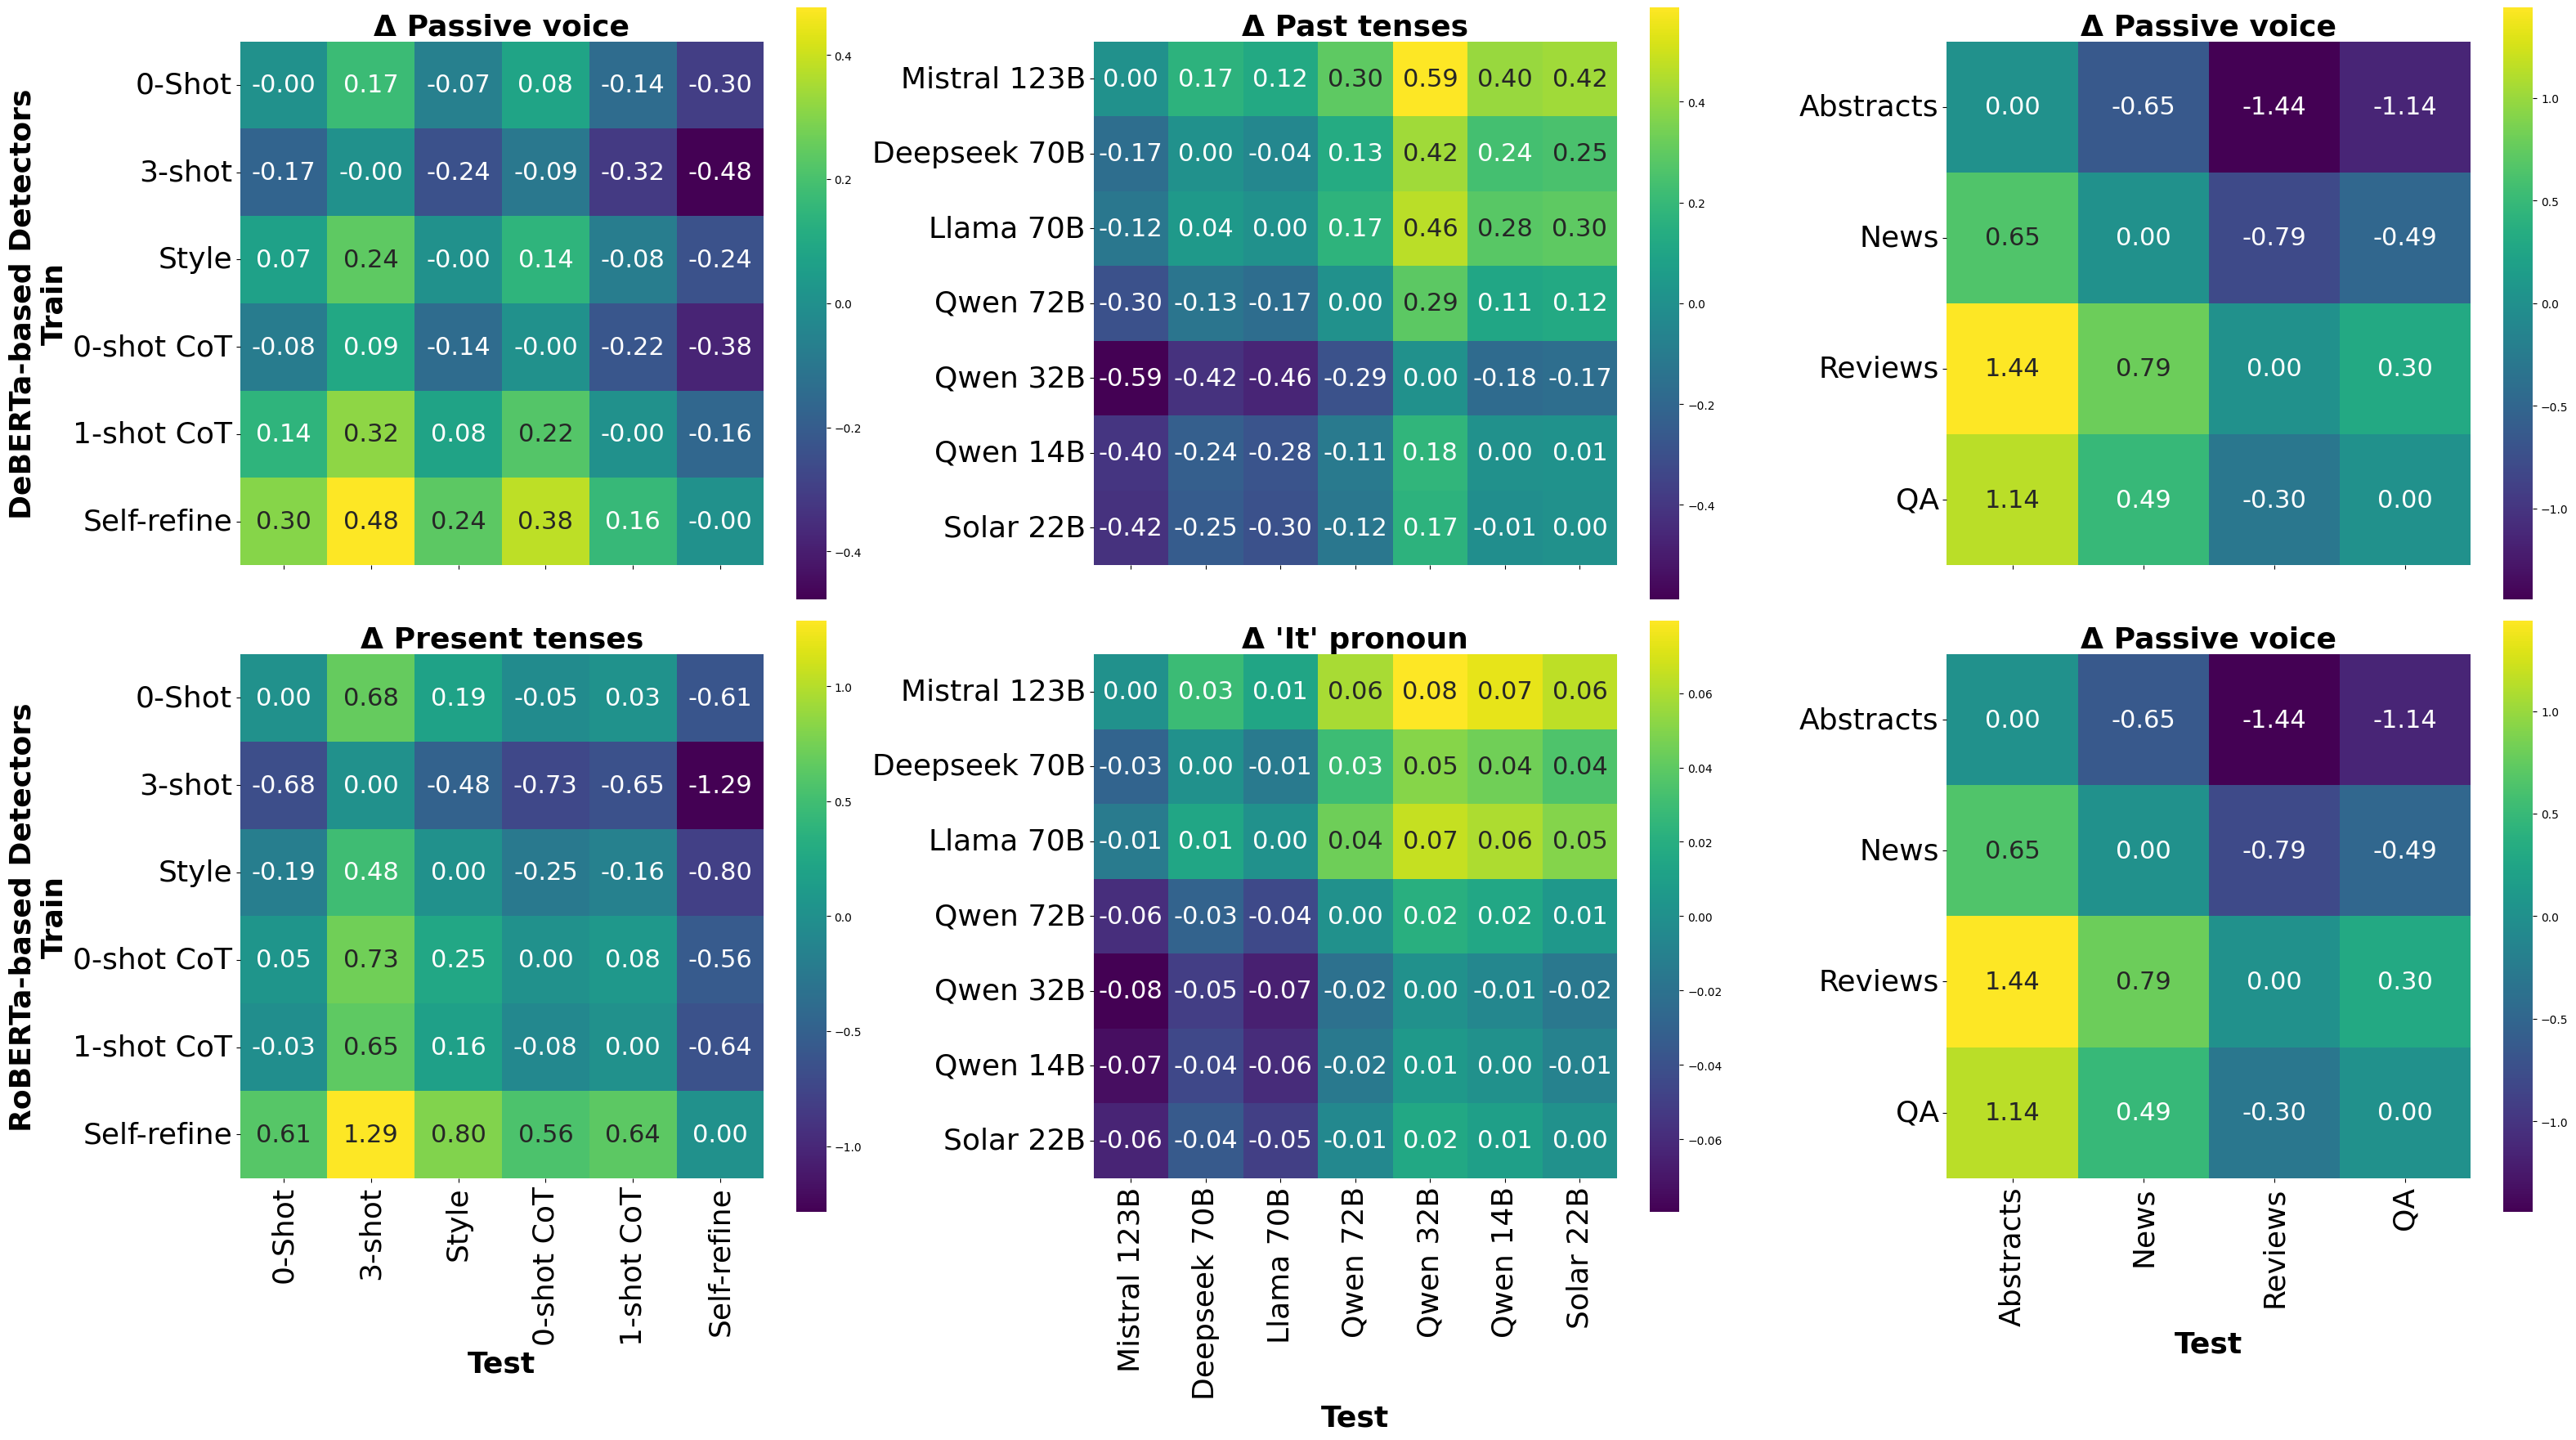

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Assuming you have 6 DataFrames: df1, df2, df3, df4, df5, df6
# If they're in a list, that would be even better:
dfs = [deberta_prompt_avg_feature_df, deberta_model_avg_feature_df, deberta_data_avg_feature_df,
       roberta_prompt_avg_feature_df, roberta_model_avg_feature_df, roberta_data_avg_feature_df]
print(len(dfs[0]))
# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(2, 3, figsize=(32, 18))

# Use ImageGrid for better colorbar control
# grid = ImageGrid(fig, 111,
#                  nrows_ncols=(2, 3),
#                  axes_pad=0.5,
#                  share_all=False,
#                  cbar_location="right",
#                  cbar_mode="edge",
#                  cbar_size="5%",
#                  cbar_pad=0.5)

# Calculate min/max for each column to share color scales vertically
# col_mins = [min(dfs[i].min().min(), dfs[i+3].min().min()) for i in range(3)]
# col_maxs = [max(dfs[i].max().max(), dfs[i+3].max().max()) for i in range(3)]

# Colorblind-friendly colormap
cmap = 'viridis'
features = [['Passive voice', 'Past tenses', 'Passive voice'], 
            ['Present tenses', "'It' pronoun", 'Passive voice']]
det_model = ['DeBERTa', 'RoBERTa']

for row in range(2):
    for col in range(3):
        ax = axes[row, col]
        df_idx = row * 3 + col
        sns.heatmap(dfs[df_idx],
                    ax=ax,
                    cmap=cmap,
                    # vmin=col_mins[col],
                    # vmax=col_maxs[col],
                    # cbar=row==0,  # Only show colorbar for first row
                    annot=True,
                    fmt=".2f",
                    annot_kws={"size": 22},
                    square=True)
        
        
        
        ax.set_title('Δ '  +  features[row][col], fontsize=26, fontweight='bold')
            # ax.tick_params(labelsize=28, fontweight='bold')

        if col == 0:
            ax.set_yticklabels(["0-Shot", "3-shot", "Style", "0-shot CoT", "1-shot CoT", "Self-refine"],fontsize=26, rotation=0) 
            ax.set_xticklabels(["0-Shot", "3-shot", "Style", "0-shot CoT", "1-shot CoT", "Self-refine"], fontsize=26,rotation=90) 
        elif col==1:
            ax.set_yticklabels(["Mistral 123B", "Deepseek 70B", "Llama 70B", "Qwen 72B",  "Qwen 32B",  "Qwen 14B", "Solar 22B"],fontsize=26, rotation=0)
            ax.set_xticklabels(["Mistral 123B", "Deepseek 70B", "Llama 70B", "Qwen 72B",  "Qwen 32B",  "Qwen 14B", "Solar 22B"], fontsize=26, rotation=90)
        else:
            ax.set_yticklabels(["Abstracts", "News", "Reviews", "QA"], fontsize=26,rotation=0)
            ax.set_xticklabels(["Abstracts", "News", "Reviews", "QA"], fontsize=26, rotation=90)

        
        if row == 0:
            ax.set_xticklabels([]) 
            ax.set_xlabel('')
        else:
            ax.set_xlabel('Test', fontsize=26, fontweight='bold',)
        
        # Always show y-axis label
        if col == 0:
            if row == 0:
                ax.set_ylabel('DeBERTa-based Detectors\nTrain', fontsize=26, fontweight='bold',)
            else:
                ax.set_ylabel('RoBERTa-based Detectors\nTrain', fontsize=26, fontweight='bold',)
        else:
            ax.set_ylabel('')

# Adjust layout
plt.tight_layout(pad=1, w_pad=0.5)
plt.savefig('plots/avg_feature_heatmap.pdf', bbox_inches='tight', format='pdf')
plt.show()

## Detail analysis

In [18]:
prompt_corr_df = pd.read_csv('heatmap_corr/prompt_corr_result.csv')
prompt_corr_df = prompt_corr_df[prompt_corr_df['significant']==True]
roberta_prompt_corr_df = prompt_corr_df[prompt_corr_df['detection_model']=='xlm-roberta-base']
sum_df = pd.DataFrame([])
sum_df['metric'] = metrics
per_df = []
mean_corr_df = []
max_corr_df = []
max_corr_model = []
max_corr_data = []
for metric in metrics.keys():
    if metric not in roberta_prompt_corr_df['metric'].values:
        per_df.append(0)
        mean_corr_df.append(0)
        max_corr_df.append(0)
        max_corr_model.append('')
        max_corr_data.append('')
    else:
        metric_corr_df = roberta_prompt_corr_df[roberta_prompt_corr_df['metric']==metric]
        per_df.append(len(metric_corr_df)/len(roberta_prompt_corr_df))

        absolute_list = [abs(i) for i in metric_corr_df['correlation'].values]
        mean_corr_df.append(np.array(absolute_list).mean())
        max_corr_df.append(max(absolute_list))
        max_corr_data.append(metric_corr_df['dataset'].values[absolute_list.index(max(absolute_list))])
        max_corr_model.append(metric_corr_df['model'].values[absolute_list.index(max(absolute_list))])
sum_df['roberta_prompt_per'] = per_df
sum_df['roberta_prompt_mean'] = mean_corr_df
sum_df['roberta_prompt_max'] = max_corr_df
sum_df['roberta_prompt_max_data'] = max_corr_data
sum_df['roberta_prompt_max_model'] = max_corr_model

In [19]:
sum_df.sort_values('roberta_prompt_max', ascending=False
                   )

,metric,roberta_prompt_per,roberta_prompt_mean,roberta_prompt_max,roberta_prompt_max_data,roberta_prompt_max_model
AVG_SENT_LEN,[],0.013021,0.467708,0.757795,reviews,llama3.3
GUNNING_FOG,[],0.011719,0.516368,0.752864,reviews,llama3.3
SHORT_SENTS,[],0.016927,0.486580,0.748086,reviews,llama3.3
L_ITS_PRON,[],0.005208,0.474781,0.733791,reviews,llama3.3
L_THEM_PRON,[],0.013021,0.498474,0.727847,qa,deepseek
...,...,...,...,...,...,...
L_YOU_PRON,[],0.005208,0.442823,0.533549,qa,solar
L_HIMSELF_PRON,[],0.009115,0.431172,0.527769,abstracts,deepseek
L_SECOND_PERSON_PRON,[],0.005208,0.444493,0.527451,abstracts,deepseek
L_THEIRS_PRON,[],0.005208,0.435548,0.478473,qa,deepseek


In [20]:
sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]


metric                            []
roberta_prompt_per          0.013021
roberta_prompt_mean         0.467708
roberta_prompt_max          0.757795
roberta_prompt_max_data      reviews
roberta_prompt_max_model    llama3.3
Name: AVG_SENT_LEN, dtype: object

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_corr_heatmap(acc_df, feature_df, feature, x_stick=False):
    dfs = [acc_df, feature_df]
    # Create figure with 1 row and 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(20, 9.5))  # Adjust figsize as needed
    cmap = 'viridis'
    det_model = ['Δ Generalization', 'Δ '+feature  ]
    for col in range(2):
        ax = axes[col]
        df_idx = col  # Since we only have 2 figures now
        sns.heatmap(dfs[df_idx],
                    ax=ax,
                    cmap=cmap,
                    # vmin=col_mins[col],
                    # vmax=col_maxs[col],
                    annot=True,
                    fmt=".2f",
                    annot_kws={"size": 22},
                    square=True)
        

        ax.set_title(det_model[col], fontsize=26, fontweight='bold')  # Using det_model[0] for the first (and only) row

        if col == 0:
            ax.set_yticklabels(["0-Shot", "3-shot", "Style", "0-shot CoT", "1-shot CoT", "Self-refine"], 
                            fontsize=26, rotation=0) 
            
        else:  # col == 1
            ax.set_yticklabels([])
        if x_stick:
            ax.set_xticklabels(["0-Shot", "3-shot", "Style", "0-shot CoT", "1-shot CoT", "Self-refine"], 
                                fontsize=26, rotation=90) 
        else:
            ax.set_xticklabels([])
        # Always show x-axis label (since we only have one row now)
        ax.set_xlabel('', fontsize=26, fontweight='bold')
        
        # Always show y-axis label
        if col == 0:
            ax.set_ylabel('', fontsize=26, fontweight='bold')
        else:
            ax.set_ylabel('')

    # Adjust layout
    plt.tight_layout(pad=1, w_pad=0.5)
    plt.savefig('plots/sep_heatmap_' + feature+ '.pdf', bbox_inches='tight', format='pdf')
    plt.show()



None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                   -8.579046   
1            8.579046                    0.000000   
2            8.077204                   -0.501842   
3            0.787952                   -7.791094   
4           23.814008                   15.234962   
5            9.979165                    1.400119   

   style_information_style_example  chain_of_thought_zero_shot  \
0                        -8.077204                   -0.787952   
1                         0.501842                    7.791094   
2                         0.000000                    7.289252   
3                        -7.289252                    0.000000   
4                        15.736804                   23.026057   
5                         1.901961                    9.191214   

   chain_of_thought_one_shot  self-refine  
0                 -23.814008    -9.979165  
1                 -15.234962    -1.400119  
2                 -15.736804

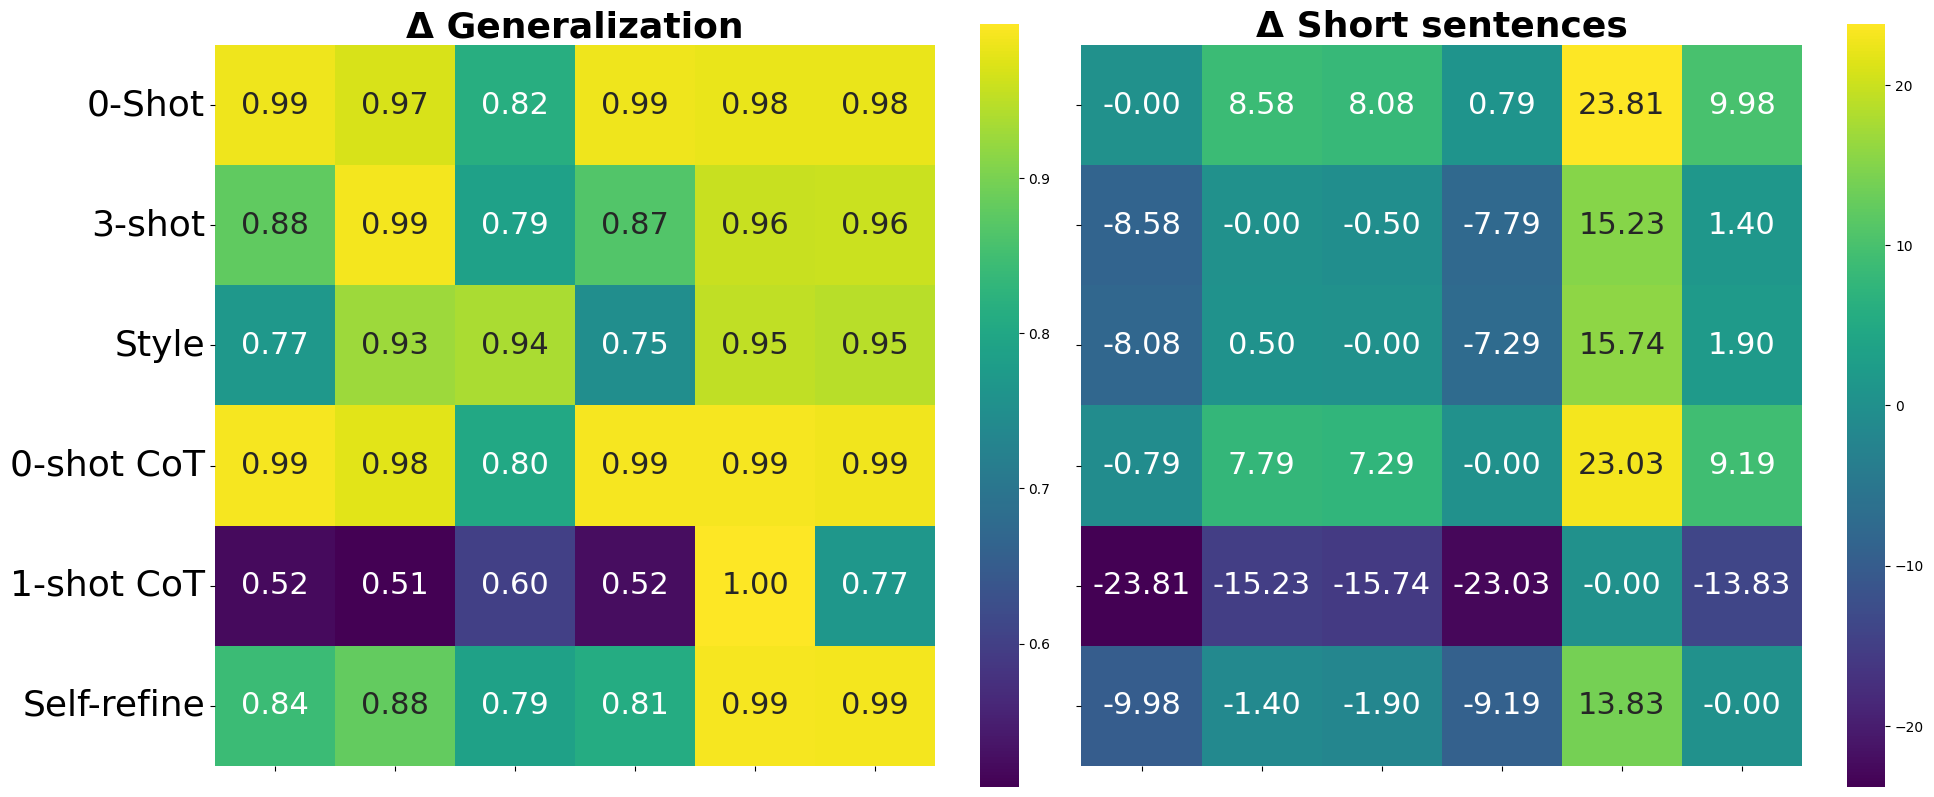

In [22]:
max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_model'] + '_' + sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_data']+ '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0].name +'_' + 'prompt_'+sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_model'] + '_' + sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_data']+ '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
print(sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_model'] + '_' + sum_df.sort_values('roberta_prompt_max', ascending=False
                   ).iloc[0]['roberta_prompt_max_data'])
plot_corr_heatmap(max_corr_acc_df, -max_corr_feature_df, feature='Short sentences')

None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                    0.011343   
1           -0.011343                    0.000000   
2            0.000483                    0.011826   
3            0.000386                    0.011729   
4           -0.002177                    0.009166   
5           -0.001811                    0.009532   

   style_information_style_example  chain_of_thought_zero_shot  \
0                        -0.000483                   -0.000386   
1                        -0.011826                   -0.011729   
2                         0.000000                    0.000097   
3                        -0.000097                    0.000000   
4                        -0.002660                   -0.002563   
5                        -0.002294                   -0.002197   

   chain_of_thought_one_shot  self-refine  
0                   0.002177     0.001811  
1                  -0.009166    -0.009532  
2                   0.002660

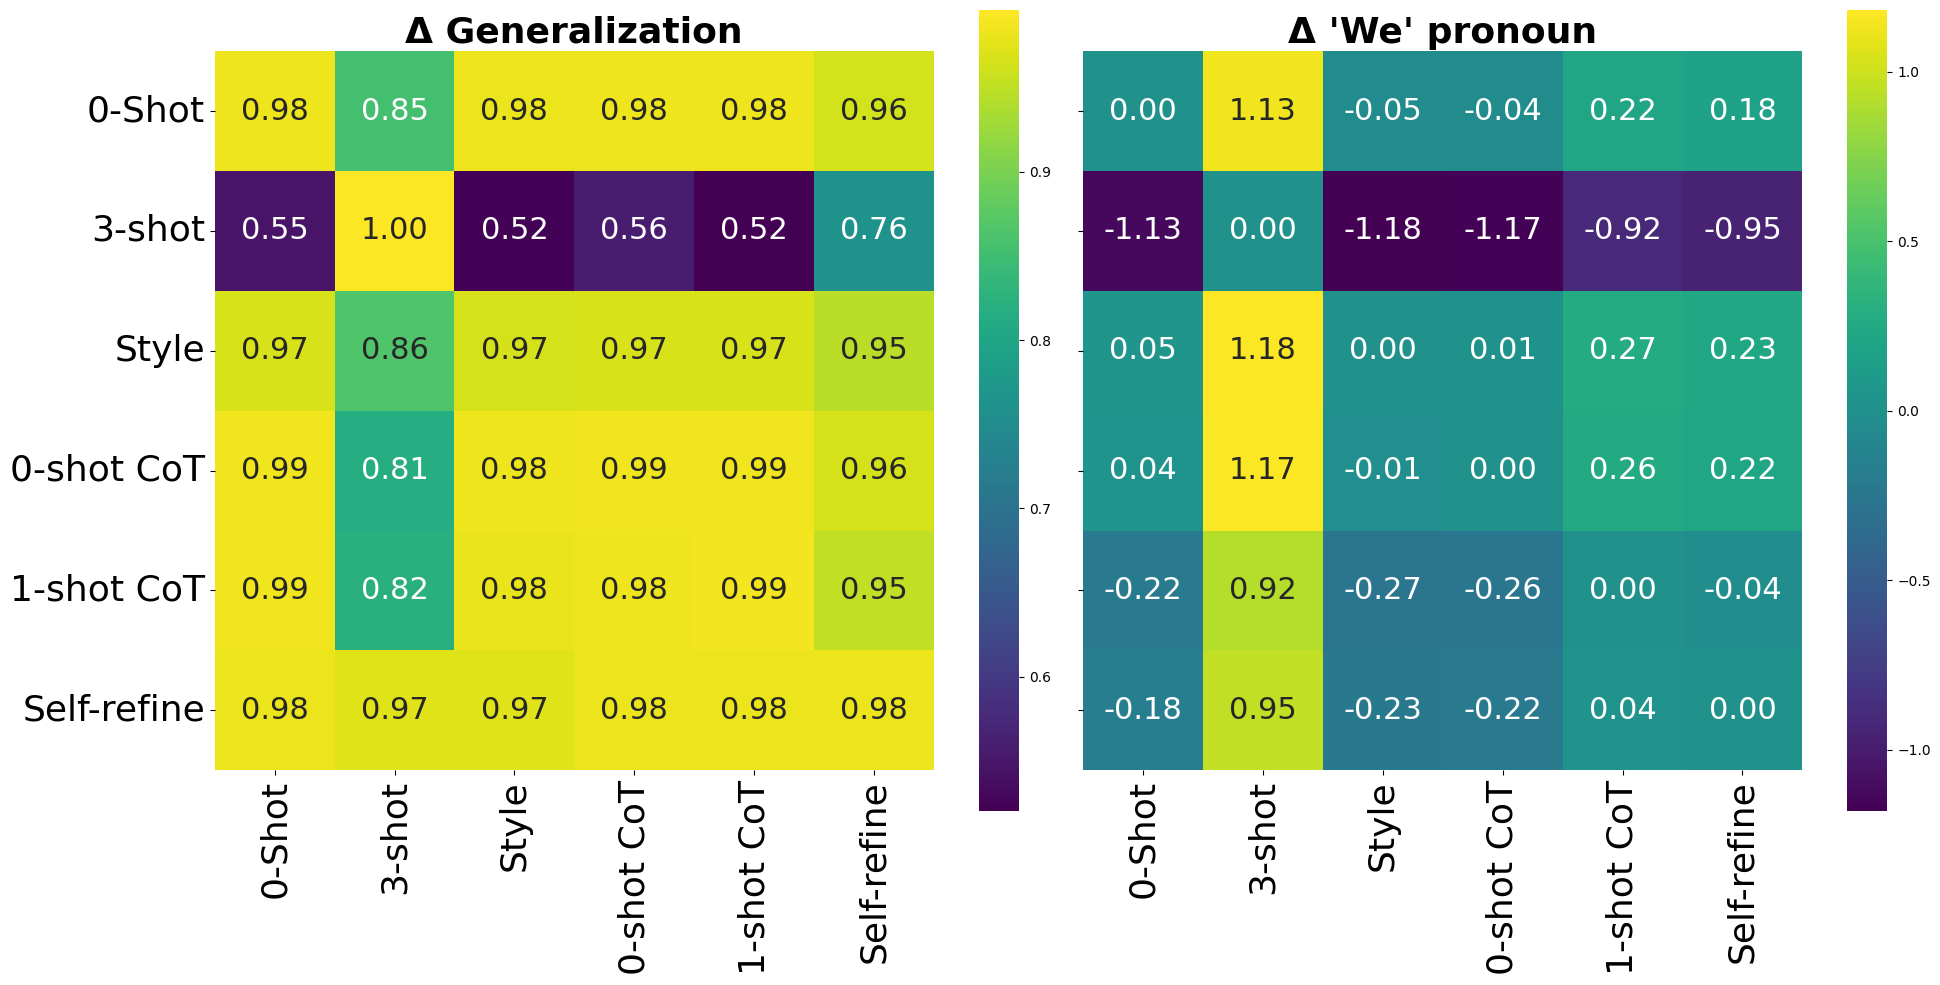

In [33]:

max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+ 'deepseek' + '_' + 'abstracts' + '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + 'L_WE_PRON' +'_' + 'prompt_'+ 'deepseek' + '_' + 'abstracts' + '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
plot_corr_heatmap(max_corr_acc_df, max_corr_feature_df*100, feature="'We' pronoun", x_stick=True
                  )

None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                   -8.139319   
1            8.139319                    0.000000   
2           -6.746230                  -14.885549   
3            1.392650                   -6.746669   
4           -3.745110                  -11.884429   
5           24.714983                   16.575665   

   style_information_style_example  chain_of_thought_zero_shot  \
0                         6.746230                   -1.392650   
1                        14.885549                    6.746669   
2                         0.000000                   -8.138880   
3                         8.138880                    0.000000   
4                         3.001120                   -5.137760   
5                        31.461213                   23.322333   

   chain_of_thought_one_shot  self-refine  
0                   3.745110   -24.714983  
1                  11.884429   -16.575665  
2                  -3.001120

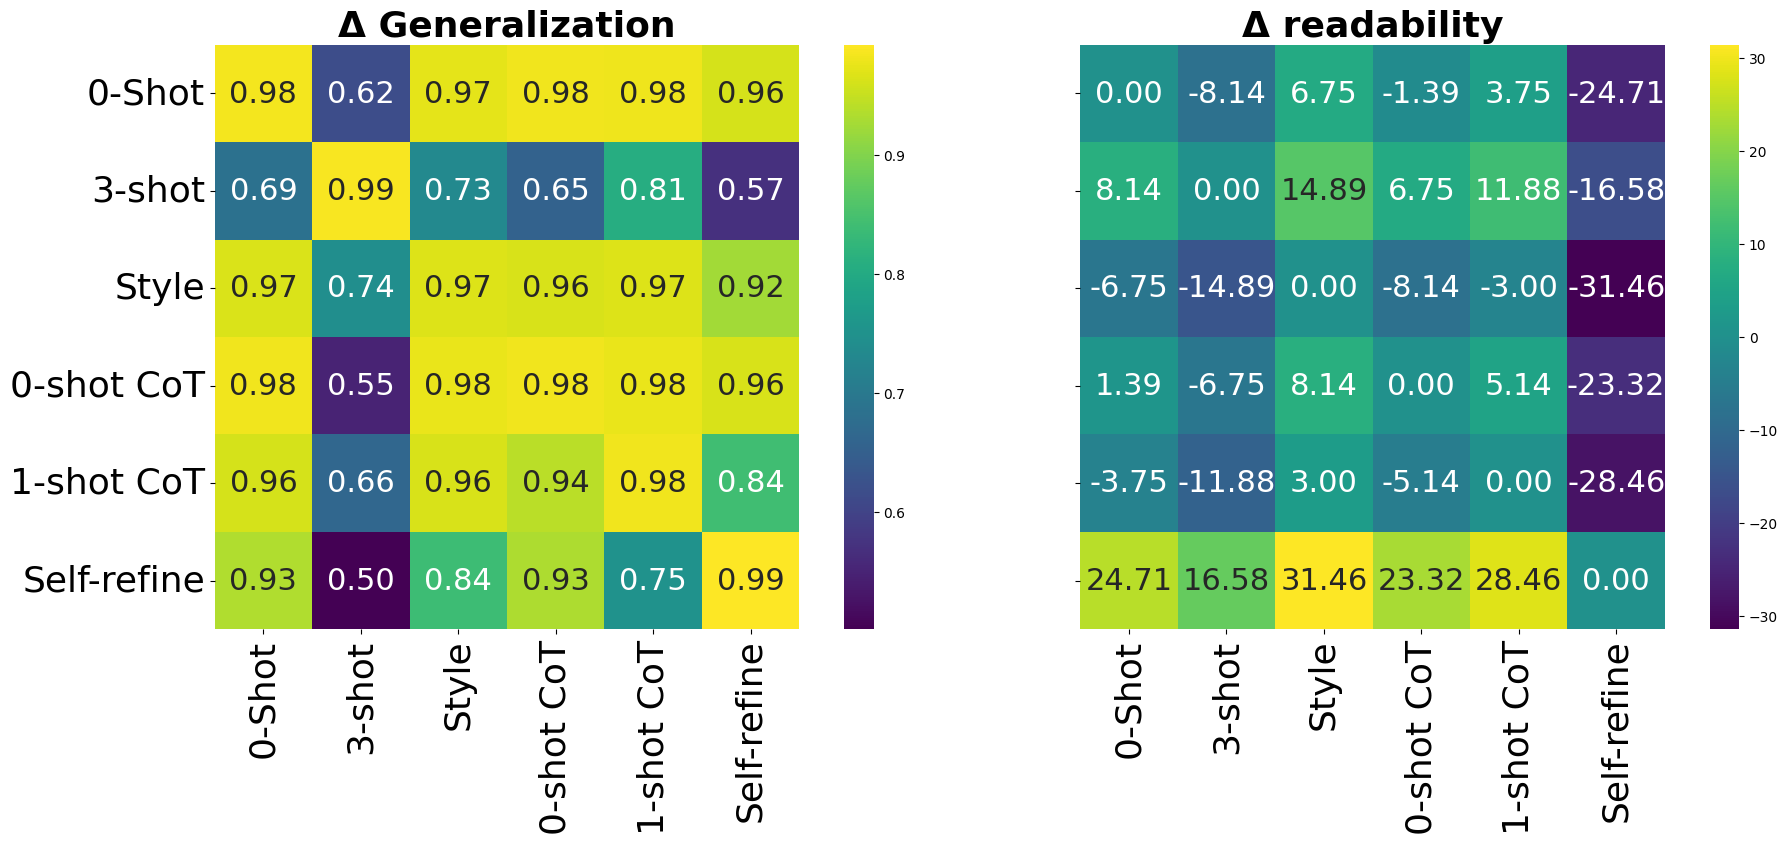

In [24]:

max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+ 'mistral' + '_' + 'abstracts' + '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + 'FLESCH' +'_' + 'prompt_'+ 'mistral' + '_' + 'abstracts' + '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
plot_corr_heatmap(max_corr_acc_df, max_corr_feature_df, feature="readability", x_stick=True
                  )

None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                   -0.144940   
1            0.144940                    0.000000   
2           -6.832553                   -6.977493   
3            2.737137                    2.592197   
4           -3.208903                   -3.353843   
5           15.959563                   15.814623   

   style_information_style_example  chain_of_thought_zero_shot  \
0                         6.832553                   -2.737137   
1                         6.977493                   -2.592197   
2                         0.000000                   -9.569690   
3                         9.569690                    0.000000   
4                         3.623650                   -5.946040   
5                        22.792117                   13.222427   

   chain_of_thought_one_shot  self-refine  
0                   3.208903   -15.959563  
1                   3.353843   -15.814623  
2                  -3.623650

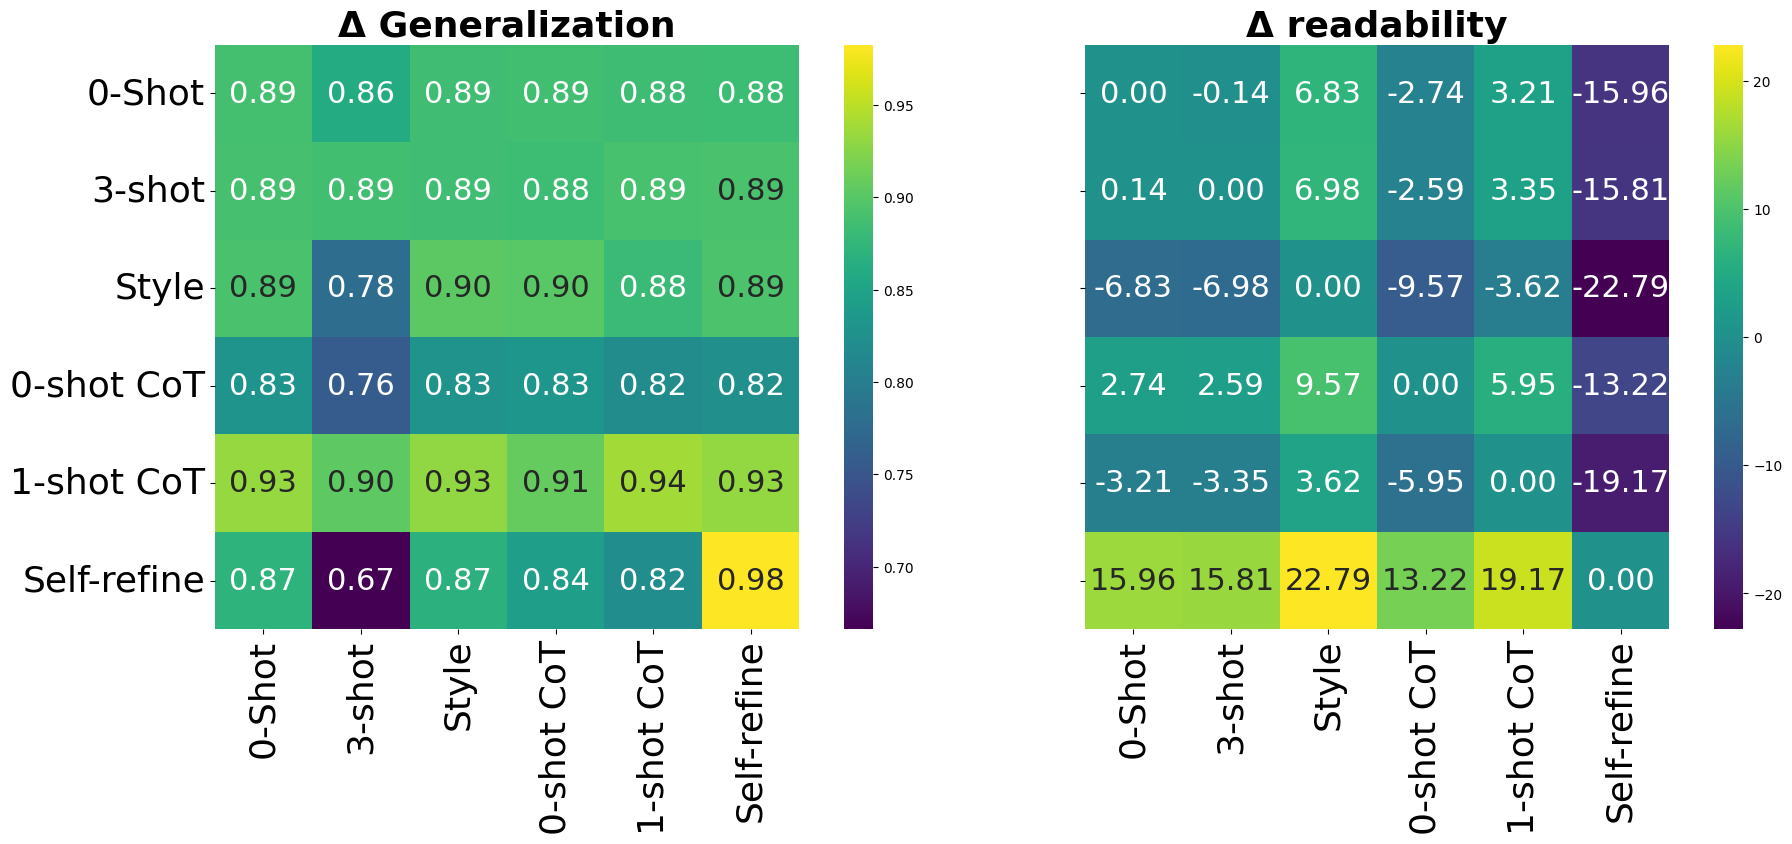

In [25]:

max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+ 'mistral' + '_' + 'qa' + '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + 'FLESCH' +'_' + 'prompt_'+ 'mistral' + '_' + 'qa' + '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
plot_corr_heatmap(max_corr_acc_df, max_corr_feature_df, feature="readability", x_stick=True
                  )

None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                   -2.482477   
1            2.482477                    0.000000   
2           -4.686940                   -7.169417   
3            4.015353                    1.532877   
4           -4.539127                   -7.021603   
5            9.121147                    6.638670   

   style_information_style_example  chain_of_thought_zero_shot  \
0                         4.686940                   -4.015353   
1                         7.169417                   -1.532877   
2                         0.000000                   -8.702293   
3                         8.702293                    0.000000   
4                         0.147813                   -8.554480   
5                        13.808087                    5.105793   

   chain_of_thought_one_shot  self-refine  
0                   4.539127    -9.121147  
1                   7.021603    -6.638670  
2                  -0.147813

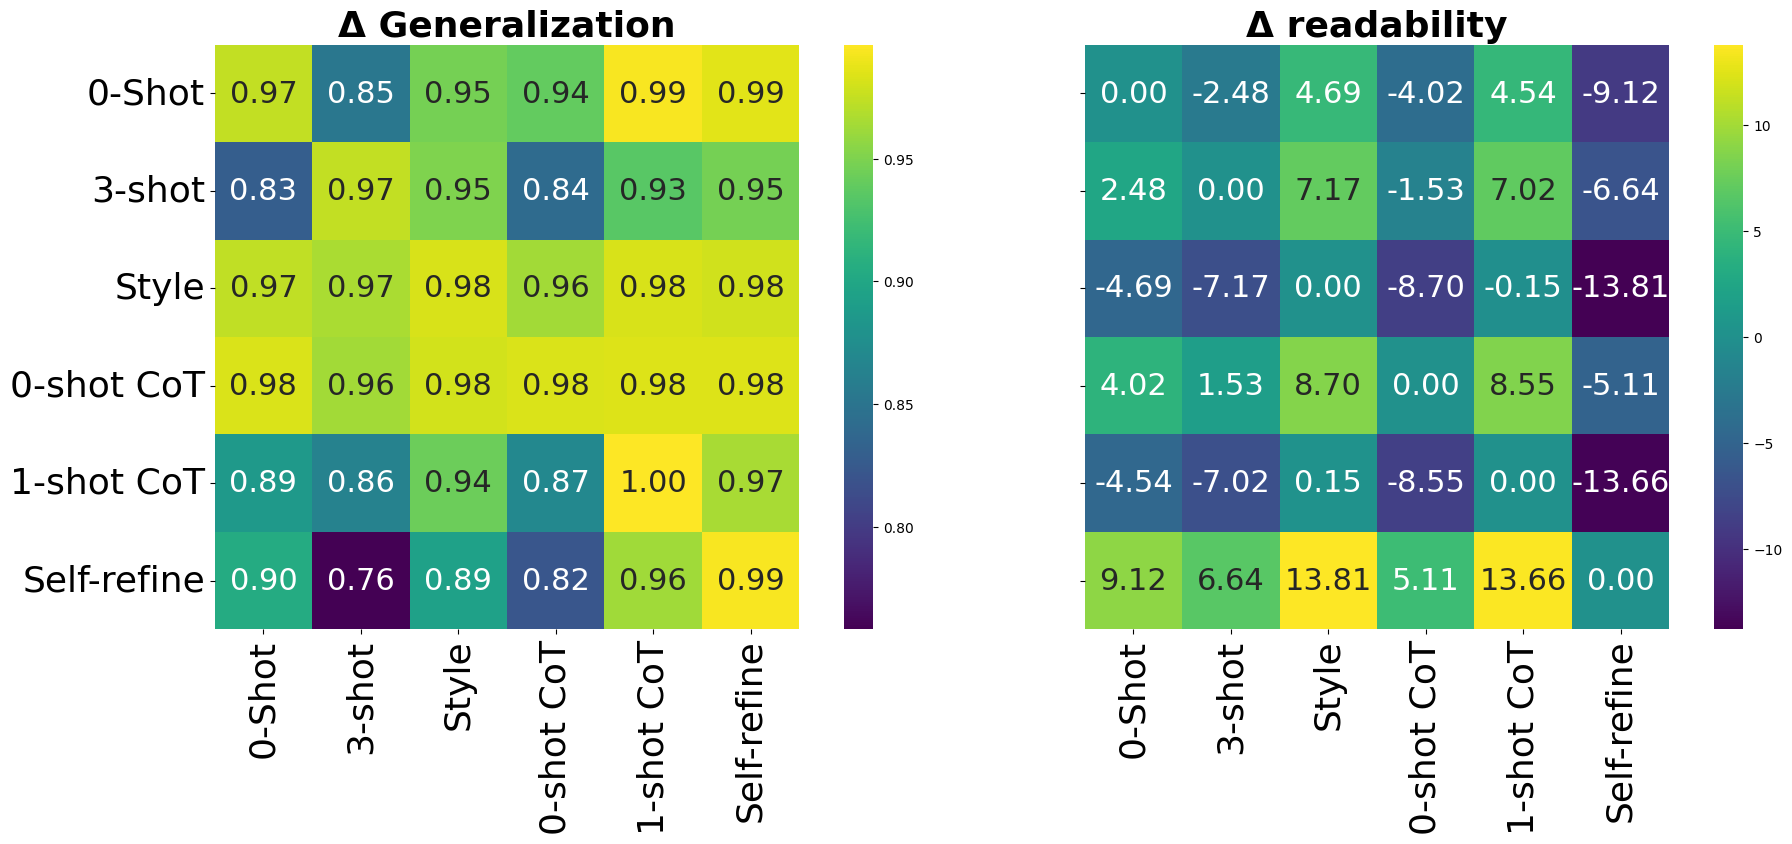

In [26]:

max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+ 'solar' + '_' + 'qa' + '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + 'FLESCH' +'_' + 'prompt_'+ 'solar' + '_' + 'qa' + '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
plot_corr_heatmap(max_corr_acc_df, max_corr_feature_df, feature="readability", x_stick=True
                  )

None
   zero_shot_baseline  in_context_learning_3-shot  \
0            0.000000                   -0.144940   
1            0.144940                    0.000000   
2           -6.832553                   -6.977493   
3            2.737137                    2.592197   
4           -3.208903                   -3.353843   
5           15.959563                   15.814623   

   style_information_style_example  chain_of_thought_zero_shot  \
0                         6.832553                   -2.737137   
1                         6.977493                   -2.592197   
2                         0.000000                   -9.569690   
3                         9.569690                    0.000000   
4                         3.623650                   -5.946040   
5                        22.792117                   13.222427   

   chain_of_thought_one_shot  self-refine  
0                   3.208903   -15.959563  
1                   3.353843   -15.814623  
2                  -3.623650

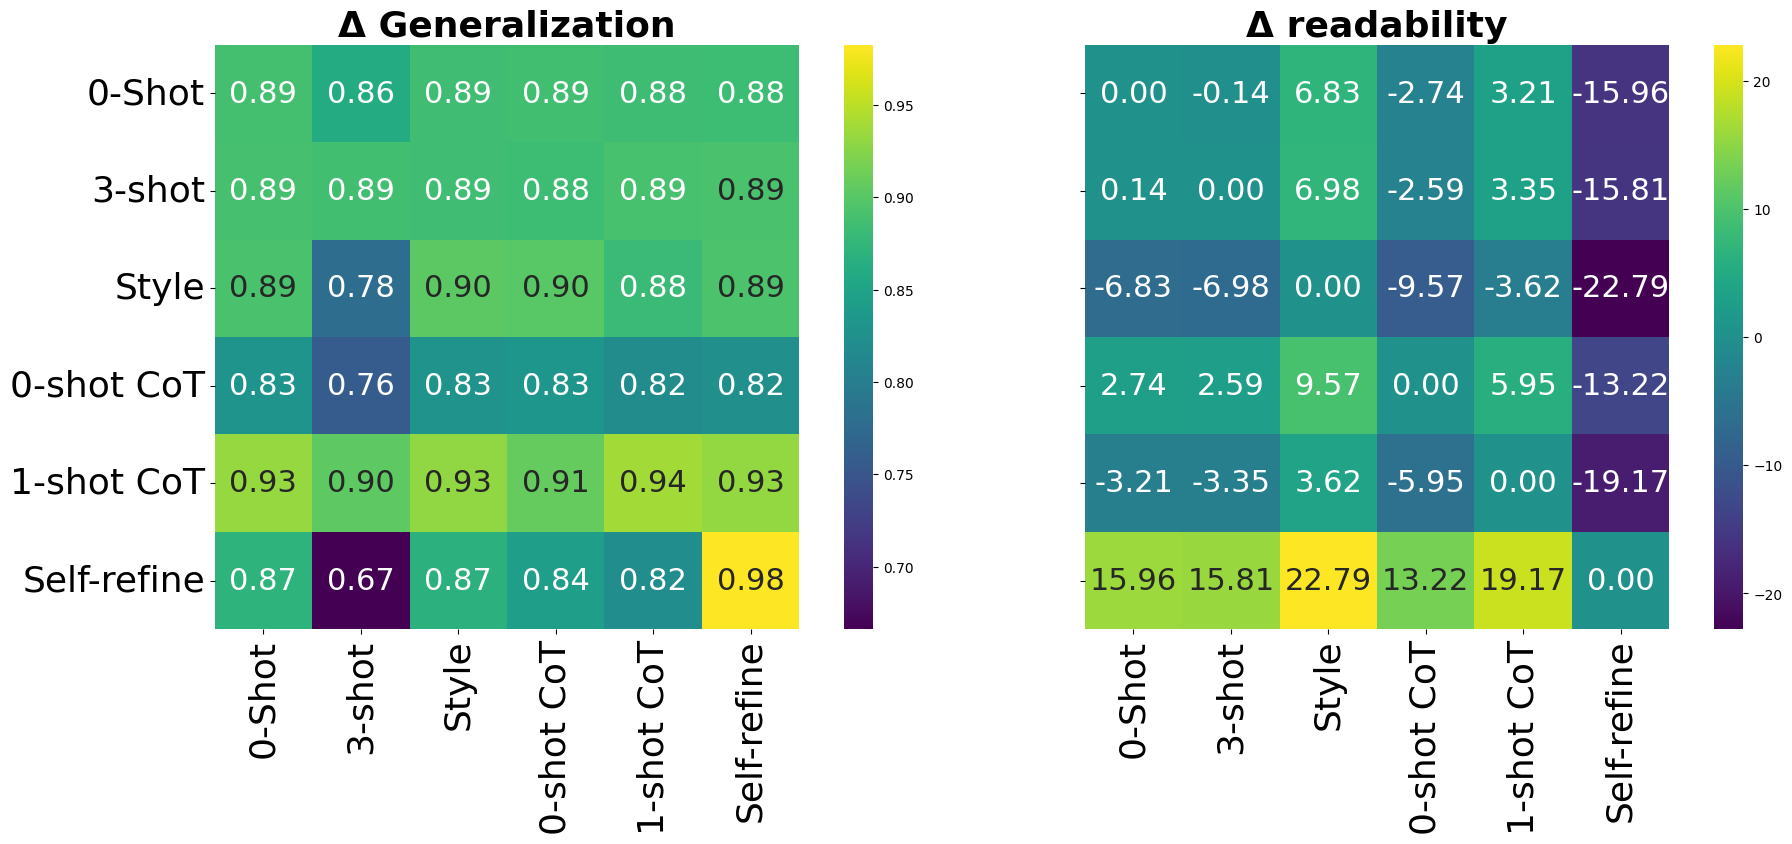

In [27]:

max_corr_acc_df = pd.read_csv('heatmap_acces/' + 'xlm-roberta-base/prompt_'+ 'mistral' + '_' + 'qa' + '.csv', index_col=0)
# max_corr_acc_df=max_corr_acc_df[1:]
max_corr_feature_df = pd.read_csv('heatmap_features/' + 'FLESCH' +'_' + 'prompt_'+ 'mistral' + '_' + 'qa' + '.csv', index_col=0)
print(max_corr_acc_df.drop('train_prompt_type', axis=1, inplace=True))
print(max_corr_feature_df)
plot_corr_heatmap(max_corr_acc_df, max_corr_feature_df, feature="readability", x_stick=True
                  )